In [1]:
import pickle as pickle

import matplotlib.pyplot as plt

from prince_cr import config, core, cross_sections, photonfields
from prince_cr.solvers import UHECRPropagationSolverBDF

CUPY not found for GPU support. Degrading to MKL.
MKL runtime not found. Degrading to scipy.


In [2]:
config.debug_level = 2
config.max_mass = 1
config.cosmic_ray_grid = (8, 13, 32)

In [3]:
pf = photonfields.CombinedPhotonField([photonfields.CMBPhotonSpectrum, photonfields.CIBGilmore2D])

cs = cross_sections.CompositeCrossSection(
    [
        (0.0, cross_sections.TabulatedCrossSection, ("PSB",)),
        (0.14, cross_sections.SophiaSuperposition, ()),
    ]
)
pr = core.PriNCeRun(max_mass=1, photon_field=pf, cross_sections=cs)

CompositeCrossSection::_join_models(): Attempt to join 2 models.
TabulatedCrossSection::_load(): Load tabulated cross sections
TabulatedCrossSection::_load(): Egrid loading finished
TabulatedCrossSection::_load(): Data file loading finished
TabulatedCrossSection::set_range(): Range set to 3.16e-04 - 1.00e+00
TabulatedCrossSection::_load(): Finished initialization
TabulatedCrossSection::_reduce_channels(): Integrating out species with lifetime smaller than inf
SophiaSuperposition::_load(): Load tabulated cross sections
SophiaSuperposition::_load(): Loading SOPHIA cross sections from file.
SophiaSuperposition::_load(): Egrid loading finished
SophiaSuperposition::_load(): Data file loading finished
SophiaSuperposition::set_range(): Range set to 1.58e-01 - 1.00e+08
TabulatedCrossSection::_reduce_channels(): Cache used for decays, CacheInfo(hits=0, misses=0, maxsize=512, currsize=0)
TabulatedCrossSection::set_range(): Range set to 3.16e-04 - 1.26e-01
SophiaSuperposition::_load(): Load tabul

In [37]:
solver = UHECRPropagationSolverBDF(initial_z=5.0, final_z=1e-5, prince_run=pr)

In [ ]:
import numpy as np

from prince_cr.cr_sources import CosmicRaySource


class ZShellSource(CosmicRaySource):
    def __init__(self, *args, z_bin: tuple[float, float], lgE_inj_bin: tuple[float, float], **kwargs):
        self.z_bin = z_bin
        self.lgE_inj_bin = lgE_inj_bin
        super().__init__(*args, **kwargs)

    def evolution(self, z) -> float:
        return super().evolution(z) if self.z_bin[0] <= z <= self.z_bin[1] else 0.0

    def injection_spectrum(self, pid, energy, params):
        lgE = np.log10(energy) + 9
        gamma = -1
        norm = 1.0
        res = np.zeros_like(lgE)
        mask = (lgE > self.lgE_inj_bin[0]) & (lgE < self.lgE_inj_bin[1])
        res[mask] = norm * energy[mask] ** (-gamma)
        return res


s = ZShellSource(prince_run=pr, z_bin=(0.0, 5.0), lgE_inj_bin=(19.0, 19.1), params={101: ()})
solver.add_source_class(s)
# solver.add_source_class(SimpleSource(princ_run=pr, params={101: (2.7, 10**20.0, 1.0)}))

In [45]:
solver.solve(dz=1e-3, verbose=False, progressbar=True)

UHECRPropagationSolverBDF::solve(): Setting up Solver
UHECRPropagationSolverBDF::solve(): Solver initialized in 0.08397102355957031 s
UHECRPropagationSolverBDF::solve(): Starting integration.


5003it [00:42, 116.47it/s]                                       

UHECRPropagationSolverBDF::solve(): Integration completed in 43.047656774520874 s


In [46]:
result = solver.res

In [47]:
ncoid2sref = result.spec_man.known_species
print(ncoid2sref)

[np.int64(0), 11, 12, 13, 14, np.int64(15), np.int64(16), 101]


In [48]:
simprop_ref = np.load("proton27.npy")

(1e+78, 1e+84)

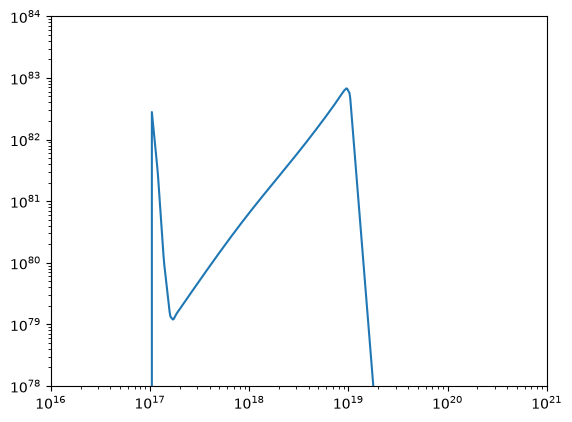

In [49]:
fig, ax = plt.subplots()

energy, spectrum = result.get_solution_group([101], epow=0)
energy *= 1e9
ax.loglog(energy, energy**3 * spectrum, "-")

# Eref, specref = simprop_ref
# specref = specref / 5.15e6
# ax.loglog(Eref, Eref**3 * specref, ".")

# ax.loglog(energy, 3.7e41 * energy**(3 - 2.7), color="k", ls="--")

ax.set_xlim(1e16, 1e21)
ax.set_ylim(1e78, 1e84)